In [4]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path.cwd()
if not (ROOT / "dataset").exists() and (ROOT.parent / "dataset").exists():
    ROOT = ROOT.parent
DATA_ROOT = ROOT / "dataset"
MITDB_ROOT = DATA_ROOT / "physionet.org" / "files" / "mitdb" / "1.0.0"

try:
    from scipy import signal, stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import wfdb
    WFDB_AVAILABLE = True
except ImportError:
    WFDB_AVAILABLE = False

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.preprocessing import StandardScaler
    from sklearn.feature_selection import SelectKBest, f_classif
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

print(f"Dataset root: {DATA_ROOT.resolve()}")
print(f"MIT-BIH records found: {len(list(MITDB_ROOT.glob('*.hea')))}")
print({"scipy": SCIPY_AVAILABLE, "wfdb": WFDB_AVAILABLE, "sklearn": SKLEARN_AVAILABLE})

Dataset root: /home/arsh/Desktop/ai in healthcare/lab 3/dataset
MIT-BIH records found: 48
{'scipy': True, 'wfdb': True, 'sklearn': True}


# Healthcare Data Across Four Modalities

This lab uses a reproducible, privacy-first workflow for **tabular**, **text**, **imaging**, and **physiological signal** data. The checked-in dataset is the real PhysioNet MIT-BIH Arrhythmia Database, so the signal modality runs locally. The other sections provide loaders and validation gates for real-world datasets when their files are supplied; they never silently replace missing clinical data with fabricated patient records.

Key principle: healthcare missingness, invalid values, label imbalance, noise, and identifiers are part of the data-generating process and must be audited before modeling.

## 1. Acquisition and provenance

| Modality | Real-world source | Local status | Model-ready target |
|---|---|---|---|
| Tabular | MIT-BIH header metadata / supplied clinical CSV | Available metadata; no patient CSV | scaled numeric tensor + encoded categorical features |
| Text | `mtsamples.csv` or an approved de-identified clinical corpus | Not checked in | PHI-redacted token sequences / TF-IDF matrix |
| Imaging | DICOM or chest X-ray folder supplied by the learner | Not checked in | anonymized, resized, normalized image tensors |
| Signal | PhysioNet MIT-BIH Arrhythmia Database | Available: `.dat`, `.hea`, `.atr` | fixed-length, filtered signal windows |

Before analysis, record source, license, download date, patient-level split strategy, and whether identifiers were removed at source.

In [5]:
# Build a real tabular dataset from MIT-BIH record headers.
# These are recording-level descriptors, not patient-level clinical outcomes.
def read_mitdb_metadata(header_path):
    lines = header_path.read_text(errors="replace").splitlines()
    record_id, _, sampling_hz, sample_count = lines[0].split()[:4]
    demographics = {}
    medications = ""
    for line in lines:
        if line.startswith("#"):
            parts = line[1:].strip().split()
            if len(parts) >= 2 and parts[0].isdigit():
                demographics["age"] = float(parts[0])
                demographics["sex"] = parts[1]
            elif line.startswith("# "):
                medications = line[2:].strip()
    return {
        "record_id": record_id,
        "sampling_hz": float(sampling_hz),
        "sample_count": int(sample_count),
        "duration_min": int(sample_count) / float(sampling_hz) / 60,
        "age": demographics.get("age", np.nan),
        "sex": demographics.get("sex", "Unknown"),
        "has_annotations": header_path.with_suffix(".atr").exists(),
        "medication_text": medications,
    }

metadata_df = pd.DataFrame(read_mitdb_metadata(path) for path in sorted(MITDB_ROOT.glob("*.hea")))
metadata_df = metadata_df.replace({"": np.nan})
# Clinical plausibility gate: impossible ages are missing, never clipped into valid-looking values.
metadata_df.loc[~metadata_df["age"].between(0, 120), "age"] = np.nan
print(metadata_df.info())
display(metadata_df.head())
print("Missingness (%):")
display((metadata_df.isna().mean() * 100).round(1).sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   record_id        48 non-null     str    
 1   sampling_hz      48 non-null     float64
 2   sample_count     48 non-null     int64  
 3   duration_min     48 non-null     float64
 4   age              46 non-null     float64
 5   sex              48 non-null     str    
 6   has_annotations  48 non-null     bool   
 7   medication_text  48 non-null     str    
dtypes: bool(1), float64(3), int64(1), str(3)
memory usage: 2.8 KB
None


,record_id,sampling_hz,sample_count,duration_min,age,sex,has_annotations,medication_text
0,100,360.0,650000,30.092593,69.0,M,True,"Aldomet, Inderal"
1,101,360.0,650000,30.092593,75.0,F,True,Diapres
2,102,360.0,650000,30.092593,84.0,F,True,The rhythm is paced with a demand pacemaker. ...
3,103,360.0,650000,30.092593,NaN,Unknown,True,"Diapres, Xyloprim"
4,104,360.0,650000,30.092593,66.0,F,True,"bursts of muscle noise occur, but the signals ..."


Missingness (%):


age                4.2
record_id          0.0
sample_count       0.0
sampling_hz        0.0
duration_min       0.0
sex                0.0
has_annotations    0.0
medication_text    0.0
dtype: float64

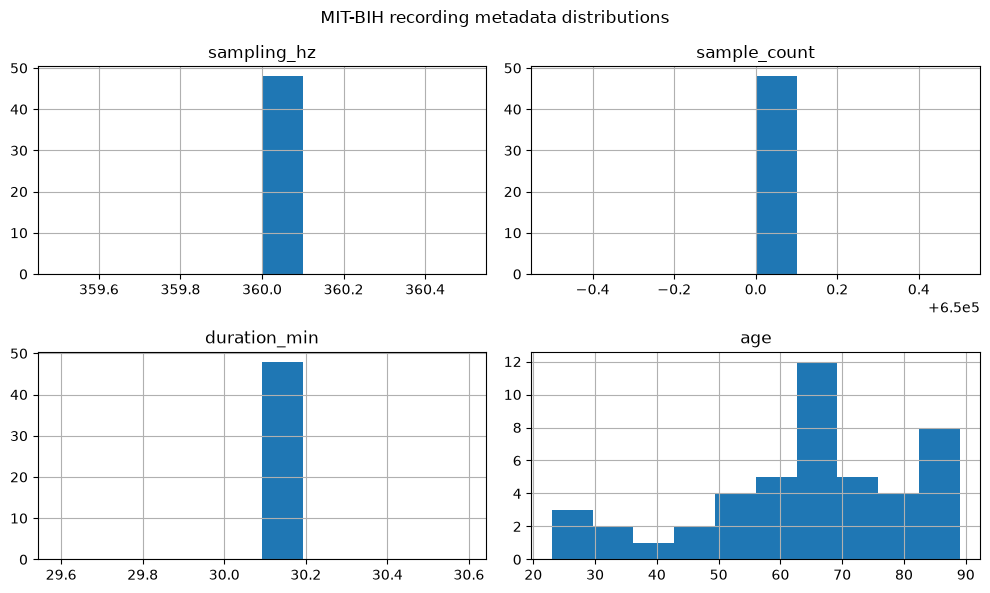

Sex balance:


sex
M          24
F          22
Unknown     2
Name: count, dtype: int64

Constant-value audit: {'sampling_hz': 1, 'sample_count': 1, 'duration_min': 1, 'age': 31}
Welch age test: statistic=-0.222, p=0.8258
Sex x age-missing contingency table:
 age_missing  False  True 
sex                      
F               22      0
M               24      0
Unknown          0      2
Chi-square: statistic=48.000, dof=2, p=3.775e-11
One-way ANOVA of age by sex: F=0.052, p=0.8214
Model-ready tabular tensor: (48, 5) float32
Selected features: ['age', 'age_missing']
Variance ratio of extracted components: [0.519 0.481]


In [7]:
## Tabular EDA, hypothesis testing, feature engineering, and selection

numeric_cols = ["sampling_hz", "sample_count", "duration_min", "age"]
metadata_df[numeric_cols].hist(figsize=(10, 6), layout=(2, 2))
plt.suptitle("MIT-BIH recording metadata distributions")
plt.tight_layout()
plt.show()
print("Sex balance:")
display(metadata_df["sex"].value_counts(dropna=False))
print("Constant-value audit:", metadata_df[numeric_cols].nunique().to_dict())

# H0: age has the same mean for male and female records.
sex_age = [group["age"].dropna().to_numpy() for sex, group in metadata_df[metadata_df["sex"].isin(["M", "F"])].groupby("sex")]
if SCIPY_AVAILABLE and len(sex_age) == 2:
    test = stats.ttest_ind(*sex_age, equal_var=False)
    print(f"Welch age test: statistic={test.statistic:.3f}, p={test.pvalue:.4g}")
else:
    print("Welch test requires scipy and both M/F age groups.")

# Chi-square test: sex and age missingness. Constant annotation status is not testable.
metadata_df["age_missing"] = metadata_df["age"].isna()
contingency = pd.crosstab(metadata_df["sex"], metadata_df["age_missing"])
print("Sex x age-missing contingency table:\n", contingency)
if SCIPY_AVAILABLE and contingency.shape[0] > 1 and contingency.shape[1] > 1:
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    print(f"Chi-square: statistic={chi2:.3f}, dof={dof}, p={p_value:.4g}")
else:
    print("Chi-square requires variation in both categorical variables.")

# One-way ANOVA: compare age across the available sex groups.
anova_groups = [group["age"].dropna().to_numpy() for _, group in metadata_df[metadata_df["sex"].isin(["M", "F"])].groupby("sex")]
if SCIPY_AVAILABLE and len(anova_groups) >= 2:
    result = stats.f_oneway(*anova_groups)
    print(f"One-way ANOVA of age by sex: F={result.statistic:.3f}, p={result.pvalue:.4g}")
else:
    print("ANOVA requires scipy and at least two non-empty groups.")

# Feature engineering, noise/missing-value handling, and extraction.
features = metadata_df[["sampling_hz", "duration_min", "age"]].copy()
features["age_missing"] = metadata_df["age_missing"].astype(int)
features["age"] = features["age"].fillna(features["age"].median())
features["duration_log"] = np.log1p(features["duration_min"])
features = (features - features.mean()) / features.std(ddof=0).replace(0, 1)
feature_tensor = features.to_numpy(dtype=np.float32)
print("Model-ready tabular tensor:", feature_tensor.shape, feature_tensor.dtype)

# Extraction with SVD is dependency-light; select non-constant features before extraction.
nonconstant = features.loc[:, features.nunique() > 1]
_, singular_values, components = np.linalg.svd(nonconstant.to_numpy(), full_matrices=False)
explained = singular_values**2 / np.sum(singular_values**2)
print("Selected features:", list(nonconstant.columns))
print("Variance ratio of extracted components:", np.round(explained, 3))

In [9]:
## Text modality: PHI removal, EDA, token sequences, and TF-IDF

# Use a supplied corpus only after verifying its provenance. The expected lab-3 file is optional.
text_path = ROOT / "mtsamples.csv"
if text_path.exists():
    text_df = pd.read_csv(text_path)
    text_col = "transcription" if "transcription" in text_df.columns else text_df.select_dtypes("object").columns[0]
    text_df["raw_text"] = text_df[text_col].fillna("")
else:
    text_df = pd.DataFrame({"raw_text": []})
    print("No clinical text corpus is checked in; PHI pipeline is defined but not run on invented notes.")

def remove_phi(text):
    text = str(text)
    patterns = [
        (r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", "[EMAIL]"),
        (r"\b(?:\+?\d{1,3}[-. ]?)?(?:\(?\d{3}\)?[-. ]?)\d{3}[-. ]?\d{4}\b", "[PHONE]"),
        (r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", "[DATE]"),
        (r"\b(?:MRN|ID|SSN)[:# ]*[A-Z0-9-]+\b", "[IDENTIFIER]"),
    ]
    for pattern, replacement in patterns:
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip().lower()

if not text_df.empty:
    text_df["clean_text"] = text_df["raw_text"].map(remove_phi)
    text_df["token_sequence"] = text_df["clean_text"].str.findall(r"\[\w+\]|[a-z]+")
    text_df["token_count"] = text_df["token_sequence"].str.len()
    display(text_df[["clean_text", "token_count"]].head())
    text_df["token_count"].hist(bins=30)
    plt.title("Clinical text length after PHI replacement")
    plt.xlabel("tokens")
    plt.show()
    if SKLEARN_AVAILABLE:
        vectorizer = TfidfVectorizer(max_features=2000, min_df=2, ngram_range=(1, 2))
        text_tensor = vectorizer.fit_transform(text_df["clean_text"]).astype(np.float32)
        print("TF-IDF tensor:", text_tensor.shape)
    else:
        print("Install scikit-learn to create the sparse TF-IDF tensor.")

No clinical text corpus is checked in; PHI pipeline is defined but not run on invented notes.


In [10]:
## Imaging modality: metadata anonymization, quality checks, augmentation, and tensors

# DICOM is optional because no images are included in this workspace.
def anonymize_dicom(path, output_path):
    try:
        import pydicom
    except ImportError as exc:
        raise ImportError("Install pydicom before processing DICOM files.") from exc
    dataset = pydicom.dcmread(path)
    # Keep only non-identifying pixels and safe technical fields in a new object.
    for keyword in ["PatientName", "PatientID", "PatientBirthDate", "PatientSex", "PatientAddress", "InstitutionName"]:
        if keyword in dataset:
            dataset.data_element(keyword).value = ""
    dataset.remove_private_tags()
    dataset.save_as(output_path)
    return dataset

def image_to_tensor(path, size=(224, 224), augment=False):
    image = Image.open(path).convert("L").resize(size)
    array = np.asarray(image, dtype=np.float32) / 255.0
    if augment:
        # A small, clinically conservative augmentation: horizontal flip only when anatomy permits.
        array = np.fliplr(array).copy()
    return array[..., None]

image_candidates = list((ROOT / "images").rglob("*") if (ROOT / "images").exists() else [])
print(f"Image files found: {len([p for p in image_candidates if p.is_file()])}")
print("Before training imaging data: remove DICOM identifiers/private tags, check orientation and pixel spacing, reject corrupt files, and split by patient rather than image.")
if not image_candidates:
    print("No imaging dataset is checked in; image tensor conversion remains ready for an approved image folder.")
else:
    image_paths = [p for p in image_candidates if p.suffix.lower() in {".png", ".jpg", ".jpeg"}]
    if image_paths:
        image_tensor = np.stack([image_to_tensor(path) for path in image_paths[:32]])
        print("Image tensor:", image_tensor.shape, image_tensor.dtype, image_tensor.min(), image_tensor.max())
        plt.imshow(image_tensor[0, ..., 0], cmap="gray")
        plt.title("Resized and normalized image")
        plt.axis("off")
        plt.show()

Image files found: 0
Before training imaging data: remove DICOM identifiers/private tags, check orientation and pixel spacing, reject corrupt files, and split by patient rather than image.
No imaging dataset is checked in; image tensor conversion remains ready for an approved image folder.


Record: 100 shape: (650000,) sampling rate: 360.0
Signal windows: (180, 3600) float64


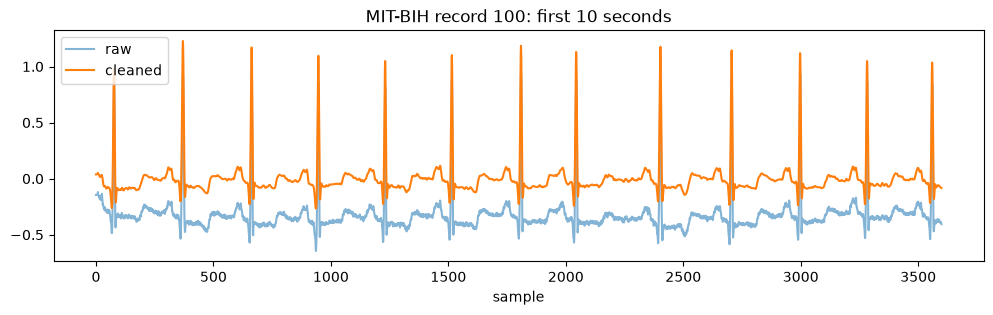

In [8]:
## Signal modality: MIT-BIH inspection, noise removal, augmentation, and windows

if not WFDB_AVAILABLE:
    print("Install wfdb to read MIT-BIH waveforms and annotations: %pip install wfdb")
else:
    records = sorted(path.stem for path in MITDB_ROOT.glob("*.hea"))
    record_id = records[0]
    record = wfdb.rdrecord(str(MITDB_ROOT / record_id))
    signal_array = record.p_signal[:, 0].astype(np.float32)
    sampling_hz = float(record.fs)
    print("Record:", record_id, "shape:", signal_array.shape, "sampling rate:", sampling_hz)

    # Robust clipping and baseline correction; do not interpolate unexplained physiologic extremes.
    signal_array = np.nan_to_num(signal_array, nan=np.nanmedian(signal_array))
    if SCIPY_AVAILABLE:
        b, a = signal.butter(3, [0.5, 40], btype="bandpass", fs=sampling_hz)
        clean_signal = signal.filtfilt(b, a, signal_array)
    else:
        clean_signal = signal_array - pd.Series(signal_array).rolling(101, center=True, min_periods=1).median().to_numpy()
    clean_signal = np.clip(clean_signal, np.quantile(clean_signal, 0.001), np.quantile(clean_signal, 0.999))

    window_seconds = 10
    window_size = int(window_seconds * sampling_hz)
    windows = np.stack([clean_signal[start:start + window_size] for start in range(0, len(clean_signal) - window_size + 1, window_size)])
    windows = (windows - windows.mean(axis=1, keepdims=True)) / (windows.std(axis=1, keepdims=True) + 1e-6)
    # Mild augmentation for training only: amplitude jitter. Never augment validation/test records.
    rng = np.random.default_rng(42)
    augmented_windows = windows * rng.normal(1.0, 0.02, size=(len(windows), 1))
    print("Signal windows:", windows.shape, windows.dtype)
    plt.figure(figsize=(12, 3))
    plt.plot(signal_array[:int(10 * sampling_hz)], alpha=0.55, label="raw")
    plt.plot(clean_signal[:int(10 * sampling_hz)], label="cleaned")
    plt.title(f"MIT-BIH record {record_id}: first 10 seconds")
    plt.xlabel("sample")
    plt.legend()
    plt.show()

## 5. Interpretation and healthcare rigor

- **Missingness:** a blank, sentinel, or impossible value can look valid; preserve a missingness indicator and document whether missingness is structural, random, or clinically informative.
- **Clinical validity:** use domain bounds and units before imputation. Do not clip an impossible age, vital sign, lab result, or waveform into a plausible value without flagging it.
- **Class imbalance:** report prevalence, use patient-level stratification, and prefer sensitivity, specificity, precision-recall, and calibration over accuracy alone.
- **Privacy:** remove PHI from text and identifiers/private tags from DICOM; treat free text, timestamps, rare conditions, and record IDs as potential re-identification risks.
- **Signal noise:** inspect raw and cleaned traces, preserve sampling metadata, filter without leaking future information, and keep augmentation out of validation/test data.
- **Leakage control:** split by patient/record before windowing, token vocabulary fitting, image augmentation, scaling, or feature selection.
- **Statistical caution:** the tests above describe this recording-level metadata, not clinical efficacy. Constant features and proxy variables must be excluded from causal or patient-level claims.

### Reproducibility checklist

1. Pin package versions and record the dataset URL, version, license, and download date.
2. Store a data dictionary with units, allowable ranges, missing-value codes, and label definitions.
3. Hash raw inputs, keep preprocessing parameters fit on training data only, and retain a provenance log.
4. Obtain appropriate ethics/IRB approval and data-use permissions before adding patient-level data.